#카메라 스티커앱 만들기

In [52]:
import cv2
import dlib
import numpy as np
import matplotlib.pyplot as plt

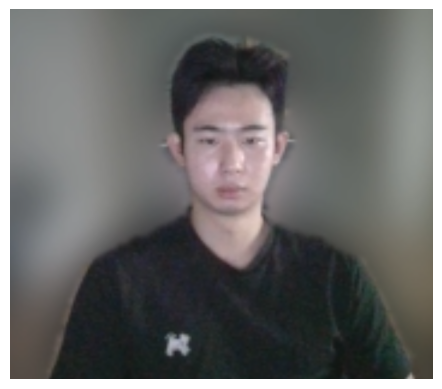

In [53]:
img_path = 'images/image1.png'  # 얼굴 사진

img_bgr = cv2.imread(img_path)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

plt.imshow(img_rgb)
plt.axis('off')
plt.show()

In [54]:
detector = dlib.get_frontal_face_detector()

predictor = dlib.shape_predictor(
    'models/shape_predictor_68_face_landmarks.dat'
)

In [55]:
faces = detector(img_rgb)

print(len(faces))

1


#CV 실행

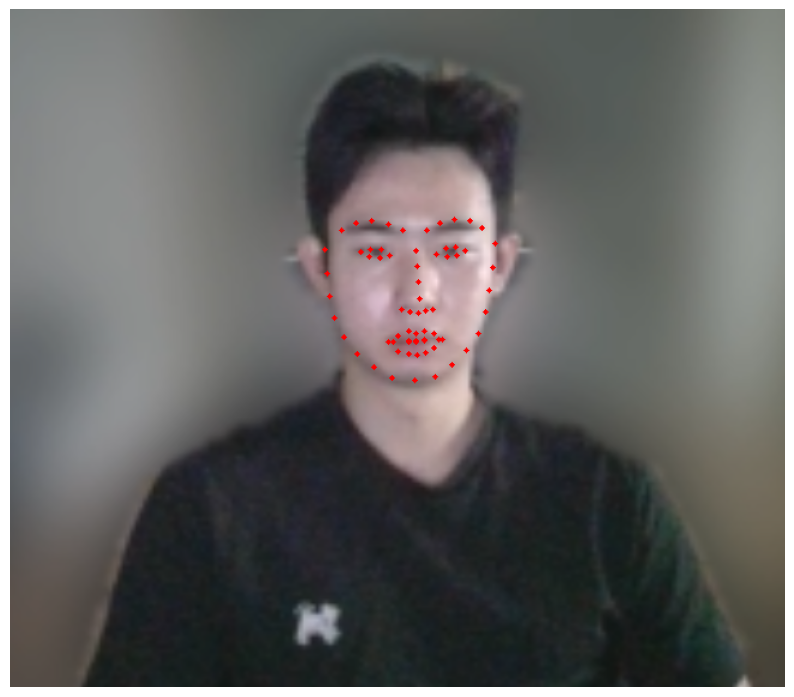

In [56]:
face = faces[0]
landmark = predictor(img_rgb, face)

for i in range(68):
    x = landmark.part(i).x
    y = landmark.part(i).y

    cv2.circle(img_rgb, (x, y), 2, (255, 0, 0), -1)

plt.figure(figsize=(10,10))
plt.imshow(img_rgb)
plt.axis('off')
plt.show()

In [57]:
for i in range(68):
    print(i, landmark.part(i).x, landmark.part(i).y)

0 262 200
1 264 220
2 266 239
3 270 257
4 278 273
5 289 287
6 303 298
7 318 307
8 337 309
9 354 306
10 368 296
11 380 284
12 390 270
13 396 252
14 399 234
15 402 215
16 404 195
17 276 184
18 288 178
19 301 176
20 315 179
21 327 184
22 347 184
23 358 178
24 370 175
25 383 176
26 393 182
27 338 201
28 339 214
29 340 227
30 341 241
31 326 250
32 333 252
33 340 253
34 346 251
35 352 250
36 292 202
37 300 200
38 309 200
39 316 205
40 308 207
41 299 206
42 355 204
43 363 199
44 371 198
45 379 201
46 372 205
47 364 206
48 315 277
49 323 272
50 332 268
51 338 270
52 345 268
53 353 270
54 360 275
55 353 282
56 346 286
57 339 288
58 332 287
59 323 285
60 319 277
61 332 276
62 338 276
63 345 275
64 357 275
65 345 276
66 338 277
67 332 277


In [58]:
x = landmark.part(33).x
y = landmark.part(33).y

print(x, y)

340 253


#수염 이미지 불러오기

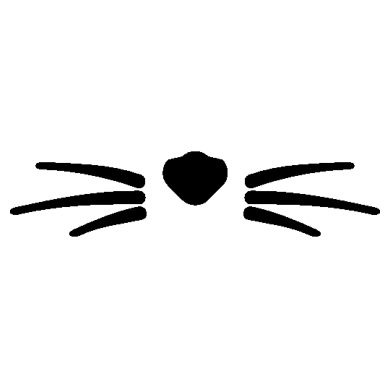

In [59]:
sticker = cv2.imread('images/cat-whiskers.png')
sticker = cv2.cvtColor(sticker, cv2.COLOR_BGR2RGB)

plt.imshow(sticker)
plt.axis('off')
plt.show()

In [60]:
face_w = face.width()

sticker_w = face_w
sticker_h = int(sticker.shape[0] * sticker_w / sticker.shape[1])

sticker = cv2.resize(sticker, (sticker_w, sticker_h))

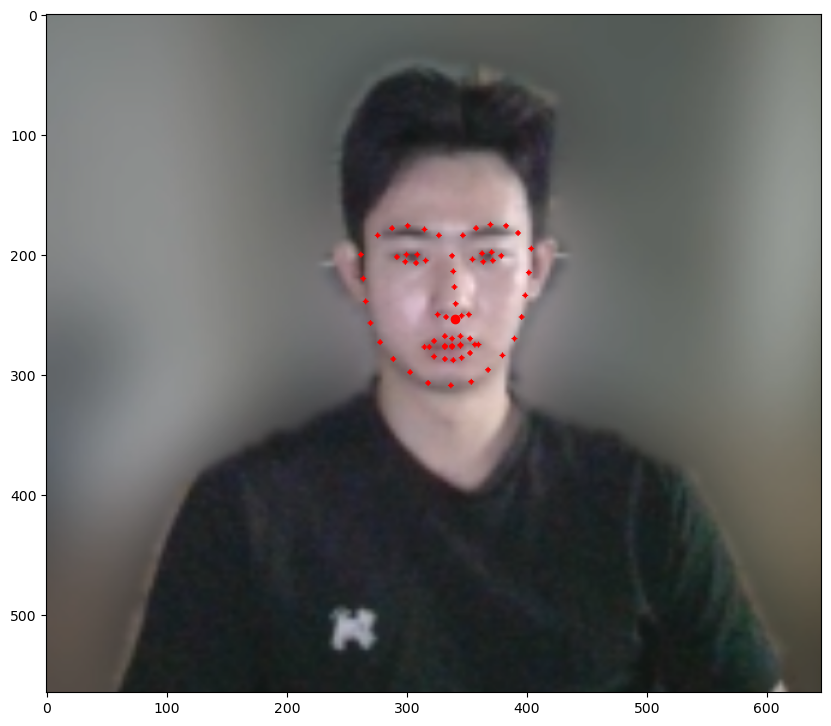

In [61]:
img_show = img_rgb.copy()

plt.figure(figsize=(10,10))
plt.imshow(img_show)
plt.scatter(x, y, c='red')
plt.show()

In [62]:
print(sticker.shape)

(150, 150, 3)


In [63]:
refined_x = x - sticker_w // 2

# 코끝보다 아래로 내리기
refined_y = y - sticker_h // 4

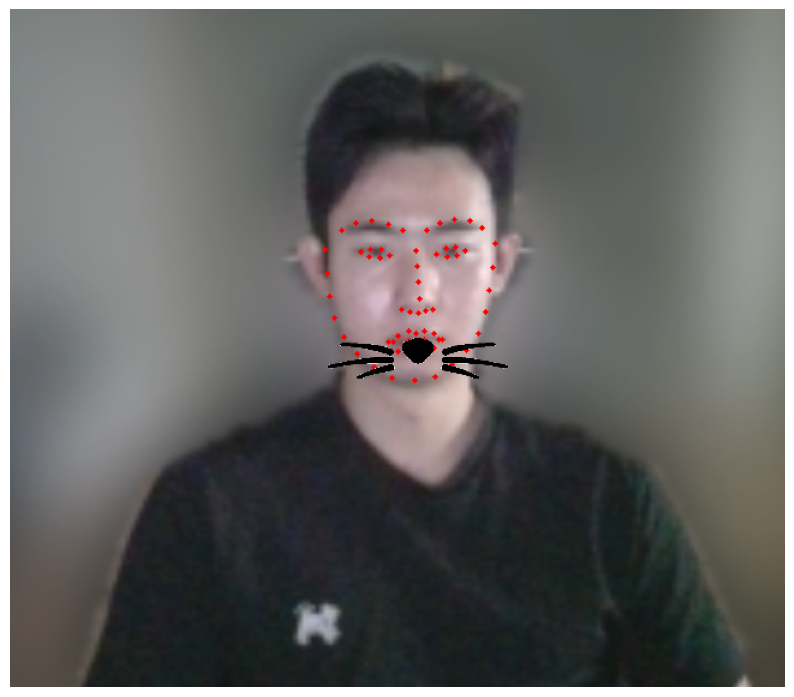

In [64]:
img_area = img_show[
    refined_y:refined_y+sticker_h,
    refined_x:refined_x+sticker_w
]

img_show[
    refined_y:refined_y+sticker_h,
    refined_x:refined_x+sticker_w
] = np.where(
    sticker > 240,
    img_area,
    sticker
)

plt.figure(figsize=(10,10))
plt.imshow(img_show)
plt.axis('off')
plt.show()

#코와 입술 사이에 수염을 붙이기 위해서 코위치에서 내렸더니 너무 많이 내려가짐

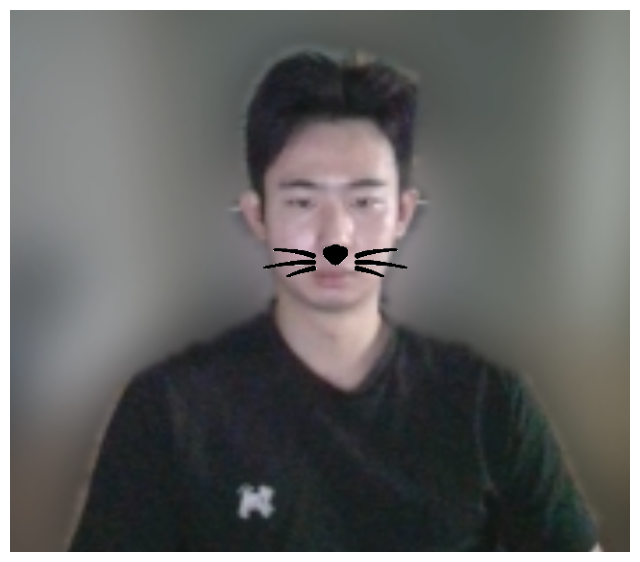

In [66]:
# 원본 이미지 복사
img_show = img_rgb.copy()

img_bgr = cv2.imread('images/image1.png')
img_rgb_clean = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

img_show = img_rgb_clean.copy()

# 코(33)와 윗입술(51) 위치
nose_x = landmark.part(33).x
nose_y = landmark.part(33).y

mouth_x = landmark.part(51).x
mouth_y = landmark.part(51).y

# 수염 기준 위치 (코와 윗입술 사이)
x = (nose_x + mouth_x) // 2
y = (nose_y + mouth_y) // 2

# 얼굴 크기에 맞춰 수염 크기 조절
face_w = face.width()

sticker_w = face_w
sticker_h = int(sticker.shape[0] * sticker_w / sticker.shape[1])

sticker_resized = cv2.resize(sticker, (sticker_w, sticker_h))

# 수염 위치 조정 (기존보다 약간 아래)
refined_x = x - sticker_w // 2
refined_y = y - int(sticker_h * 0.55) + 8

# 이미지 범위 계산
img_area = img_show[
    refined_y:refined_y + sticker_h,
    refined_x:refined_x + sticker_w
]

# 흰색 배경 제거 후 합성
img_show[
    refined_y:refined_y + sticker_h,
    refined_x:refined_x + sticker_w
] = np.where(
    sticker_resized > 240,
    img_area,
    sticker_resized
)

# 최종 결과 출력 (랜드마크 점 없음)
plt.figure(figsize=(8, 8))
plt.imshow(img_show)
plt.axis('off')
plt.show()

In [67]:
cv2.imwrite(
    'cat_whisker_result.png',
    cv2.cvtColor(img_show, cv2.COLOR_RGB2BGR)
)

True

#회고 
카메라 스티커앱 만들기를 해보았다 cv에 대해서 배우고 사진 불어오고 얼굴에 붙여보았다. 중간에 수염이 입에 붕텨지는 불상사도 있었다. 재밌었다.